<a href="https://colab.research.google.com/github/shraddhadangat/Data-Cleaning-Reporting-Automation/blob/main/Copy_of_OTT_Content_Viewer_Analytics_csv%22).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("OTT_Content_Viewer_Analytics.csv")
df.head()

,content_id,title,content_type,genre,country,region,release_year,viewer_id,watch_date,watch_duration_min,watch_hours,rating,subscription_plan,device,revenue
0,1103,New Story 1103,Movie,Comedy,Germany,North America,2026,10334,2025-01-01,137,2.28,7.0,Standard,Mobile,3.66
1,1180,Beyond Story 1180,Movie,Horror,UK,Europe,2015,10256,2025-01-01,8,0.13,7.7,Premium,TV,9.53
2,1093,Hidden Story 1093,Movie,Comedy,UK,Oceania,2026,10281,2025-01-01,117,1.95,9.2,Standard,Mobile,3.69
3,1015,The Story 1015,Movie,Sci-Fi,USA,Oceania,2024,10304,2025-01-02,101,1.68,9.2,Premium,Mobile,4.80
4,1107,City Story 1107,Series,Animation,Australia,Europe,2026,10321,2025-01-02,135,2.25,7.3,Basic,TV,5.10


In [ ]:
df.shape

(1500, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   content_id          1500 non-null   int64  
 1   title               1500 non-null   object 
 2   content_type        1500 non-null   object 
 3   genre               1500 non-null   object 
 4   country             1500 non-null   object 
 5   region              1500 non-null   object 
 6   release_year        1500 non-null   int64  
 7   viewer_id           1500 non-null   int64  
 8   watch_date          1500 non-null   object 
 9   watch_duration_min  1500 non-null   int64  
 10  watch_hours         1500 non-null   float64
 11  rating              1500 non-null   float64
 12  subscription_plan   1500 non-null   object 
 13  device              1500 non-null   object 
 14  revenue             1500 non-null   float64
dtypes: float64(3), int64(4), object(8)
memory usage: 175.9+

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)


Missing values in each column:
 content_id            0
title                 0
content_type          0
genre                 0
country               0
region                0
release_year          0
viewer_id             0
watch_date            0
watch_duration_min    0
watch_hours           0
rating                0
subscription_plan     0
device                0
revenue               0
dtype: int64


In [ ]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Remove duplicates if any
df = df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)


Number of duplicate rows: 0
Dataset shape after removing duplicates: (1500, 15)


Content count by genre:
 genre
Drama          182
Documentary    182
Horror         174
Action         170
Animation      162
Romance        160
Sci-Fi         158
Thriller       157
Comedy         155
Name: count, dtype: int64


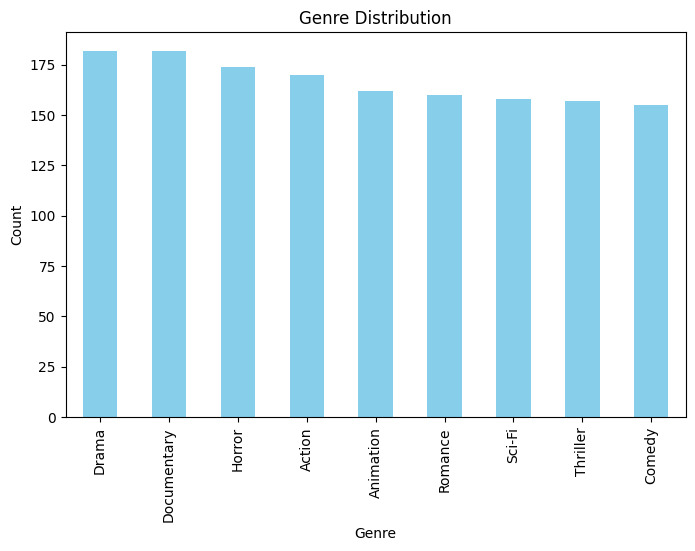

In [ ]:
#Genre-wise analysis


genre_counts = df['genre'].value_counts()
print("Content count by genre:\n", genre_counts)

# Optional: visualize genre distribution
import matplotlib.pyplot as plt

genre_counts.plot(kind='bar', figsize=(8,5), color='skyblue')
plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()



In [ ]:
# Check column names
print(df.columns)

# Clean column names
df.columns = df.columns.str.strip()

# Convert watch_date safely
df['watch_date'] = pd.to_datetime(df['watch_date'], errors='coerce')

# Drop rows with missing watch_date
df = df.dropna(subset=['watch_date'])


Index(['content_id', 'title', 'content_type', 'genre', 'country', 'region',
       'release_year', 'viewer_id', 'watch_date', 'watch_duration_min',
       'watch_hours', 'rating', 'subscription_plan', 'device', 'revenue'],
      dtype='object')


Monthly watch hours trend:
 watch_date
2025-01    115.73
2025-02     99.74
2025-03    105.77
2025-04    100.08
2025-05    111.06
2025-06    111.64
2025-07    118.51
2025-08    100.20
2025-09    105.21
2025-10    115.54
2025-11     97.13
2025-12    112.44
2026-01    104.15
2026-02     95.62
2026-03    113.97
2026-04    103.11
2026-05    105.88
2026-06    112.35
Freq: M, Name: watch_hours, dtype: float64


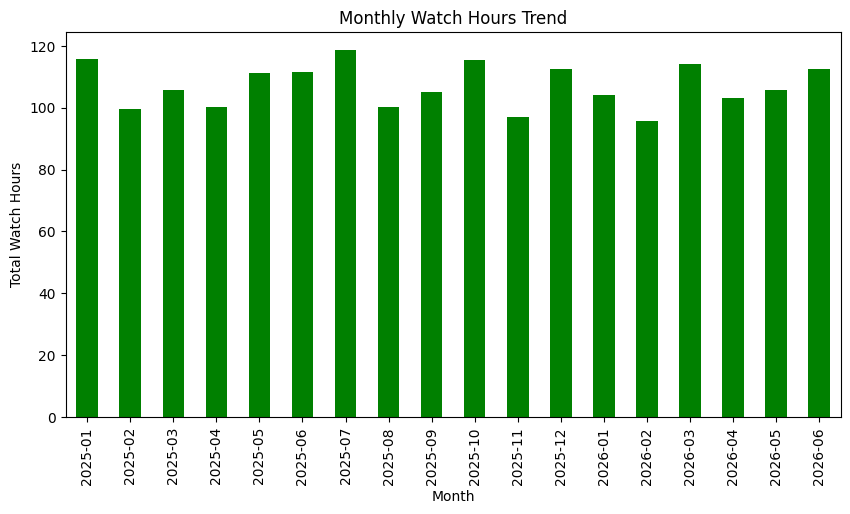

In [ ]:
# Monthly trend analysis
# Convert watch_date column to datetime
df['watch_date'] = pd.to_datetime(df['watch_date'])

# Group by month and calculate total watch hours
monthly_trend = df.groupby(df['watch_date'].dt.to_period('M'))['watch_hours'].sum()

print("Monthly watch hours trend:\n", monthly_trend)

# Visualization
import matplotlib.pyplot as plt

monthly_trend.plot(kind='bar', figsize=(10,5), color='green')
plt.title("Monthly Watch Hours Trend")
plt.xlabel("Month")
plt.ylabel("Total Watch Hours")
plt.show()


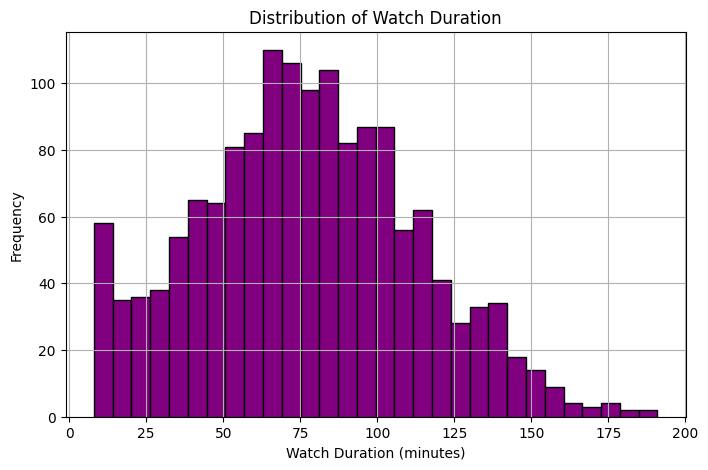

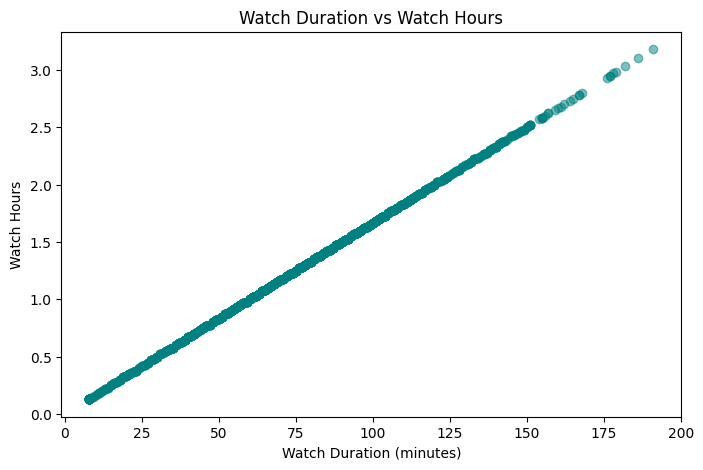

In [ ]:
# Basic visualization


import matplotlib.pyplot as plt

# Histogram of watch duration
plt.figure(figsize=(8,5))
df['watch_duration_min'].hist(bins=30, color='purple', edgecolor='black')
plt.title("Distribution of Watch Duration")
plt.xlabel("Watch Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

# Scatter plot of watch duration vs. watch hours
plt.figure(figsize=(8,5))
plt.scatter(df['watch_duration_min'], df['watch_hours'], alpha=0.5, color='teal')
plt.title("Watch Duration vs Watch Hours")
plt.xlabel("Watch Duration (minutes)")
plt.ylabel("Watch Hours")
plt.show()


In [ ]:
#Export cleaned dataset
# Save the cleaned DataFrame to a new CSV file

df.to_csv("Cleaned_OTT_Dataset.csv", index=False)

print("Cleaned dataset exported successfully!")


Cleaned dataset exported successfully!
